In [1]:
# ── BLOCK 1: Import Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# ── BLOCK 2: Load the ULB Dataset ──
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (284807, 31)


In [3]:
# ── BLOCK 3: Look at the first 5 rows ──
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ── BLOCK 4: Understand the structure ──
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# ── BLOCK 5: How many frauds vs normal transactions? ──
class_counts = df['Class'].value_counts()
print(class_counts)
print()
print(f"Normal transactions: {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent transactions: {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")

Class
0    284315
1       492
Name: count, dtype: int64

Normal transactions: 284315 (99.83%)
Fraudulent transactions: 492 (0.17%)


C:\Users\Dhwani\AppData\Local\Temp\ipykernel_23144\1130178506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])


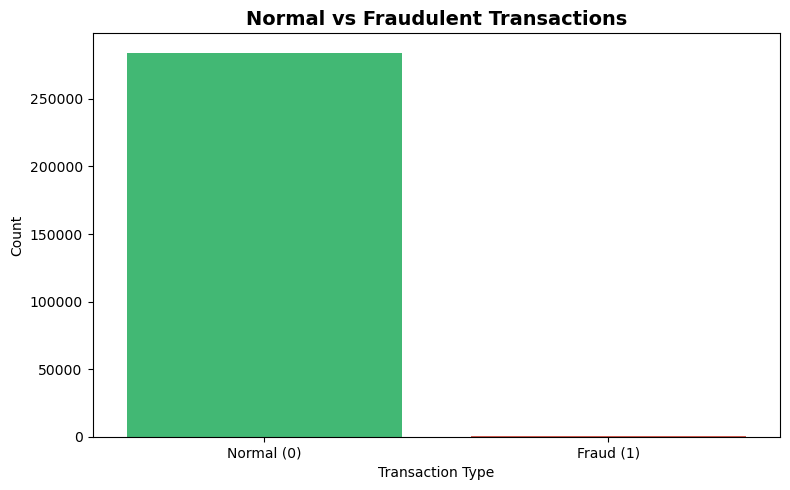

Chart saved to results folder!


In [6]:
# ── BLOCK 6: Visualise Class Imbalance ──
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Normal vs Fraudulent Transactions', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("../results/class_imbalance.png")
plt.show()
print("Chart saved to results folder!")

In [7]:
# ── BLOCK 7: Understand the Amount column ──
print("=== Transaction Amount Statistics ===")
print(df['Amount'].describe())
print()
print(f"Minimum amount: €{df['Amount'].min():.2f}")
print(f"Maximum amount: €{df['Amount'].max():.2f}")
print(f"Average amount: €{df['Amount'].mean():.2f}")
print(f"Median amount:  €{df['Amount'].median():.2f}")
print()
print("=== Amount Statistics FOR FRAUD ONLY ===")
print(df[df['Class']==1]['Amount'].describe())

=== Transaction Amount Statistics ===
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Minimum amount: €0.00
Maximum amount: €25691.16
Average amount: €88.35
Median amount:  €22.00

=== Amount Statistics FOR FRAUD ONLY ===
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


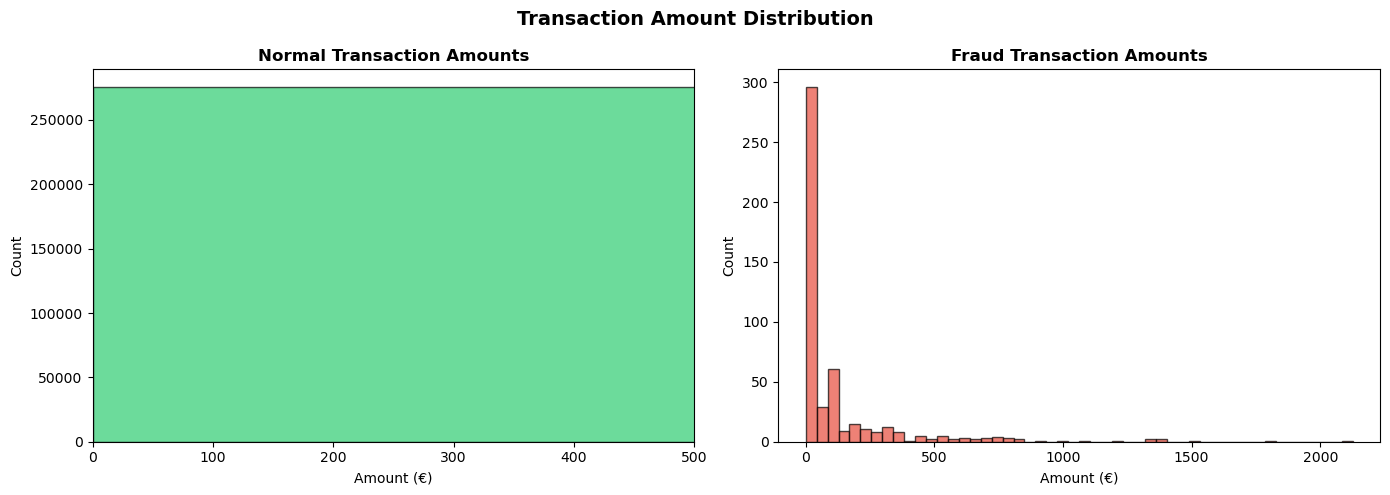

Chart saved!


In [8]:
# ── BLOCK 8: Visualise Amount Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All transactions
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, 
             color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_title('Normal Transaction Amounts', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 500)

# Fraud only
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, 
             color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Fraud Transaction Amounts', fontweight='bold')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Count')

plt.suptitle('Transaction Amount Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/amount_distribution.png")
plt.show()
print("Chart saved!")

In [9]:
# ── BLOCK 9: Build the Risk Matrix ──
# Based on actual data distribution we just explored

def assign_risk_tier(amount):
    if amount <= 22:
        return 'Low'
    elif amount <= 77:
        return 'Medium'
    elif amount <= 500:
        return 'High'
    else:
        return 'Critical'

# Apply to every transaction
df['Risk_Tier'] = df['Amount'].apply(assign_risk_tier)

# See how many transactions fall in each tier
print("=== Risk Tier Distribution ===")
print(df['Risk_Tier'].value_counts())
print()

# See how frauds distribute across tiers
print("=== Fraud Distribution Across Risk Tiers ===")
fraud_by_tier = df[df['Class']==1]['Risk_Tier'].value_counts()
print(fraud_by_tier)
print()

# Percentage of frauds in each tier
print("=== % of Frauds in Each Tier ===")
for tier in ['Low', 'Medium', 'High', 'Critical']:
    tier_total = len(df[df['Risk_Tier']==tier])
    tier_frauds = len(df[(df['Risk_Tier']==tier) & (df['Class']==1)])
    pct = (tier_frauds/tier_total)*100
    print(f"{tier}: {tier_frauds} frauds out of {tier_total} transactions ({pct:.3f}%)")

=== Risk Tier Distribution ===
Risk_Tier
Low         142643
Medium       70898
High         62124
Critical      9142
Name: count, dtype: int64

=== Fraud Distribution Across Risk Tiers ===
Risk_Tier
Low         271
High        139
Medium       47
Critical     35
Name: count, dtype: int64

=== % of Frauds in Each Tier ===
Low: 271 frauds out of 142643 transactions (0.190%)
Medium: 47 frauds out of 70898 transactions (0.066%)
High: 139 frauds out of 62124 transactions (0.224%)
Critical: 35 frauds out of 9142 transactions (0.383%)
